# AtliQ Hotels Revenue & Occupancy Analytics

## Professional Data Analyst Portfolio Project

**Tools:** Python • Pandas • NumPy • Matplotlib

---

### Executive objective

AtliQ Hotels wants to understand how its properties are performing across **revenue, occupancy, booking channels, cancellations and customer experience**.

This project converts raw hotel booking data into an analysis-ready dataset, validates data quality, develops business KPIs, identifies performance gaps and translates the findings into actionable recommendations.

### Business questions

1. Which cities and properties contribute the most realized revenue?
2. Which properties and room classes have the strongest occupancy?
3. How different are weekday and weekend demand patterns?
4. Which booking platforms generate the most revenue?
5. Where is cancellation/revenue leakage highest?
6. Which properties are high performers, opportunities or turnaround candidates?
7. What actions could management investigate based on the observed patterns?

> **Portfolio positioning:** This is presented as an end-to-end analytics case study rather than as a classroom exercise.


## Portfolio Version — Final Repository Structure

This notebook is built for the repository structure:

```text
atliq-hotels-revenue-occupancy-analytics/
├── data/
│   ├── raw/
│   │   ├── dim_date.csv
│   │   ├── dim_hotels.csv
│   │   ├── dim_rooms.csv
│   │   ├── fact_aggregated_bookings.csv
│   │   ├── fact_bookings.csv
│   │   └── new_data_august.csv
│   └── processed/
├── notebooks/
│   └── AtliQ_Hotels_Portfolio_Analysis_FINAL.ipynb
├── outputs/
│   ├── figures/
│   └── reports/
└── src/
```

**There is no `datasets/` folder requirement.**

The data-loading section automatically checks both common Jupyter working-directory situations:
- project root → `data/raw`
- notebook directory → `../data/raw`


## 1. Project Structure

The notebook is designed for this repository structure:

```text
atliq-hotels-revenue-occupancy-analytics/
│
├── data/
│   ├── raw/
│   │   ├── dim_date.csv
│   │   ├── dim_hotels.csv
│   │   ├── dim_rooms.csv
│   │   ├── fact_aggregated_bookings.csv
│   │   ├── fact_bookings.csv
│   │   └── new_data_august.csv
│   │
│   └── processed/
│
├── notebooks/
│   └── AtliQ_Hotels_Portfolio_Analysis.ipynb
│
├── outputs/
│   ├── figures/
│   └── reports/
│
├── src/
├── README.md
├── requirements.txt
└── .gitignore
```

### Path design

Because this notebook lives inside `notebooks/`, the raw datasets are one level above it:

```text
notebooks/
   ↓
../data/raw/
```

The path logic below is deliberately robust to common Jupyter launch locations.


In [1]:
# ============================================================
# 2. Imports & Notebook Configuration
# ============================================================

from pathlib import Path
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Use Matplotlib defaults; no custom color palette is required.
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

print("Python / Pandas environment loaded successfully.")


Python / Pandas environment loaded successfully.


## 3. Robust Dataset Path

The most common source of errors when moving a notebook into a professional repository is a relative-path mismatch.

This notebook first looks for `data/raw` relative to the notebook's expected location and then checks common project-root alternatives.

**You should not need a `datasets/` folder.**


In [2]:
# ============================================================
# 3. Locate data/raw robustly
# ============================================================

required_files = [
    "dim_date.csv",
    "dim_hotels.csv",
    "dim_rooms.csv",
    "fact_aggregated_bookings.csv",
    "fact_bookings.csv",
]

cwd = Path.cwd()

candidate_dirs = [
    cwd / "data" / "raw",          # if Jupyter starts at project root
    cwd.parent / "data" / "raw",   # if notebook is opened from notebooks/
]

DATA_DIR = next(
    (p for p in candidate_dirs if all((p / f).exists() for f in required_files)),
    None
)

if DATA_DIR is None:
    searched = "\n".join(str(p.resolve()) for p in candidate_dirs)
    raise FileNotFoundError(
        "Could not locate the required data/raw folder.\n\n"
        f"Searched:\n{searched}\n\n"
        "Expected files:\n" + "\n".join(required_files)
    )

print("Data directory:")
print(DATA_DIR.resolve())


Data directory:
C:\Users\prasa\OneDrive\Desktop\code basic\python\project\atliq-hotels-revenue-occupancy-analytics\data\raw


## 4. Load Source Data

The supplied project contains two fact tables and three dimensions:

| Dataset | Role |
|---|---|
| `fact_bookings` | Booking-level transactions |
| `fact_aggregated_bookings` | Date/property/room-level booking and capacity data |
| `dim_hotels` | Property, city and hotel category |
| `dim_rooms` | Room code and room class |
| `dim_date` | Calendar/date attributes |

`new_data_august.csv` is treated as an optional incremental file.


In [3]:
# ============================================================
# 4. Load datasets
# ============================================================

df_date = pd.read_csv(DATA_DIR / "dim_date.csv")
df_hotels = pd.read_csv(DATA_DIR / "dim_hotels.csv")
df_rooms = pd.read_csv(DATA_DIR / "dim_rooms.csv")
df_agg_bookings = pd.read_csv(DATA_DIR / "fact_aggregated_bookings.csv")
df_bookings = pd.read_csv(DATA_DIR / "fact_bookings.csv")

august_path = DATA_DIR / "new_data_august.csv"
df_august = pd.read_csv(august_path) if august_path.exists() else None

print("All required datasets loaded successfully.")
print()
print("dim_date:", df_date.shape)
print("dim_hotels:", df_hotels.shape)
print("dim_rooms:", df_rooms.shape)
print("fact_aggregated_bookings:", df_agg_bookings.shape)
print("fact_bookings:", df_bookings.shape)

if df_august is not None:
    print("new_data_august:", df_august.shape)
else:
    print("new_data_august: not found (optional)")


All required datasets loaded successfully.

dim_date: (92, 4)
dim_hotels: (25, 4)
dim_rooms: (4, 2)
fact_aggregated_bookings: (9200, 5)
fact_bookings: (134590, 12)
new_data_august: (7, 13)


In [4]:
# Dataset overview
datasets = {
    "dim_date": df_date,
    "dim_hotels": df_hotels,
    "dim_rooms": df_rooms,
    "fact_aggregated_bookings": df_agg_bookings,
    "fact_bookings": df_bookings,
}

overview = pd.DataFrame({
    "dataset": list(datasets.keys()),
    "rows": [d.shape[0] for d in datasets.values()],
    "columns": [d.shape[1] for d in datasets.values()],
    "duplicate_rows": [d.duplicated().sum() for d in datasets.values()],
    "missing_cells": [d.isna().sum().sum() for d in datasets.values()],
})

overview


,dataset,rows,columns,duplicate_rows,missing_cells
0,dim_date,92,4,0,0
1,dim_hotels,25,4,0,0
2,dim_rooms,4,2,0,0
3,fact_aggregated_bookings,9200,5,0,2
4,fact_bookings,134590,12,0,77910


## 5. Data Understanding

Before transforming the data, inspect the structure and business fields.

The booking-level table contains information such as booking ID, property, dates, guests, room category, booking platform, booking status, ratings and revenue fields.

The aggregated booking table contains successful bookings and capacity, which is the basis for occupancy analysis.


In [5]:
# Inspect column names and data types
for name, data in datasets.items():
    print(f"\n{'=' * 70}\n{name.upper()}\n{'=' * 70}")
    print("Columns:", list(data.columns))
    display(data.head(3))
    display(data.dtypes.to_frame("dtype"))



DIM_DATE
Columns: ['date', 'mmm yy', 'week no', 'day_type']


,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday


,dtype
date,str
mmm yy,str
week no,str
day_type,str



DIM_HOTELS
Columns: ['property_id', 'property_name', 'category', 'city']


,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi


...

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.00
1,19562,1-May-22,RT1,28,30.00
2,19563,1-May-22,RT1,23,30.00


,dtype
property_id,int64
check_in_date,str
room_category,str
successful_bookings,int64
capacity,float64



FACT_BOOKINGS
Columns: ['booking_id', 'property_id', 'booking_date', 'check_in_date', 'checkout_date', 'no_guests', 'room_category', 'booking_platform', 'ratings_given', 'booking_status', 'revenue_generated', 'revenue_realized']


,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.00,RT1,direct online,1.00,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.00,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.00,RT1,logtrip,5.00,Checked Out,9100000,9100


,dtype
booking_id,str
property_id,int64
booking_date,str
check_in_date,str
checkout_date,str
no_guests,float64
room_category,str
booking_platform,str
ratings_given,float64
booking_status,str


In [6]:
# Key business dimensions
print("Hotel cities:")
print(df_hotels["city"].value_counts())

print("\nHotel categories:")
print(df_hotels["category"].value_counts())

print("\nRoom categories:")
print(df_bookings["room_category"].value_counts(dropna=False))

print("\nBooking platforms:")
print(df_bookings["booking_platform"].value_counts(dropna=False))

print("\nBooking status:")
print(df_bookings["booking_status"].value_counts(dropna=False))


Hotel cities:
city
Mumbai       8
Hyderabad    6
Bangalore    6
Delhi        5
Name: count, dtype: int64

Hotel categories:
category
Luxury      16
Business     9
Name: count, dtype: int64

Room categories:
room_category
RT2    49505
RT1    38446
RT3    30566
RT4    16073
Name: count, dtype: int64

Booking platforms:
booking_platform
others            55066
makeyourtrip      26898
logtrip           14756
direct online     13379
tripster           9630
journey            8106
direct offline     6755
Name: count, dtype: int64

Booking status:
booking_status
Checked Out    94411
Cancelled      33420
No Show         6759
Name: count, dtype: int64


## 6. Data Quality Assessment

The quality checks cover:

- missing values
- duplicates
- invalid guest counts
- revenue outliers
- missing capacity
- bookings exceeding capacity
- date parsing validity

The objective is to make cleaning decisions explicit and reproducible.


In [7]:
# Missing values
missing = (
    pd.concat(
        [
            df_date.isna().sum().rename("dim_date"),
            df_hotels.isna().sum().rename("dim_hotels"),
            df_rooms.isna().sum().rename("dim_rooms"),
            df_agg_bookings.isna().sum().rename("fact_aggregated_bookings"),
            df_bookings.isna().sum().rename("fact_bookings"),
        ],
        axis=1
    )
    .fillna(0)
    .astype(int)
)

missing[missing.sum(axis=1) > 0].sort_values(
    "fact_bookings", ascending=False
)


,dim_date,dim_hotels,dim_rooms,fact_aggregated_bookings,fact_bookings
ratings_given,0,0,0,0,77907
no_guests,0,0,0,0,3
capacity,0,0,0,2,0


In [8]:
# Duplicate checks
duplicate_summary = pd.DataFrame({
    "dataset": list(datasets.keys()),
    "duplicate_rows": [d.duplicated().sum() for d in datasets.values()],
})

duplicate_summary


,dataset,duplicate_rows
0,dim_date,0
1,dim_hotels,0
2,dim_rooms,0
3,fact_aggregated_bookings,0
4,fact_bookings,0


## 7. Data Cleaning Rules

### Rule 1 — Invalid guest counts
Records where `no_guests <= 0` are treated as invalid.

### Rule 2 — Revenue outliers
`revenue_generated` is reviewed using the mean + 3 standard deviations. Extreme observations beyond this analytical threshold are excluded from the cleaned analysis.

### Rule 3 — Ratings
Missing ratings are **not** replaced with the mean. Missing means no rating was recorded.

### Rule 4 — Capacity
Missing capacity values are filled using the median capacity.

### Rule 5 — Impossible occupancy
Records where `successful_bookings > capacity` are treated as invalid.

### Rule 6 — Dates
The source dates use a day-first representation. We explicitly use `dayfirst=True` to avoid ambiguous date interpretation.


In [9]:
# ============================================================
# 7. Cleaning pipeline
# ============================================================

bookings = df_bookings.copy()
agg = df_agg_bookings.copy()
hotels = df_hotels.copy()
rooms = df_rooms.copy()
dates = df_date.copy()

# --- Invalid guest counts ---
invalid_guest_count = (bookings["no_guests"] <= 0).sum()
bookings = bookings[bookings["no_guests"] > 0].copy()

# --- Revenue outliers ---
revenue_mean = bookings["revenue_generated"].mean()
revenue_std = bookings["revenue_generated"].std()
revenue_upper_limit = revenue_mean + 3 * revenue_std

revenue_outlier_count = (
    bookings["revenue_generated"] > revenue_upper_limit
).sum()

bookings = bookings[
    bookings["revenue_generated"] <= revenue_upper_limit
].copy()

# --- Capacity ---
missing_capacity_count = agg["capacity"].isna().sum()
agg["capacity"] = agg["capacity"].fillna(agg["capacity"].median())

invalid_capacity_count = (
    agg["successful_bookings"] > agg["capacity"]
).sum()

agg = agg[
    agg["successful_bookings"] <= agg["capacity"]
].copy()

# --- Explicit date parsing ---
dates["date"] = pd.to_datetime(
    dates["date"], dayfirst=True, errors="coerce"
)

for col in ["booking_date", "check_in_date", "checkout_date"]:
    if col in bookings.columns:
        bookings[col] = pd.to_datetime(
            bookings[col], dayfirst=True, errors="coerce"
        )

if "check_in_date" in agg.columns:
    agg["check_in_date"] = pd.to_datetime(
        agg["check_in_date"], dayfirst=True, errors="coerce"
    )

cleaning_summary = pd.DataFrame({
    "Cleaning Check": [
        "Invalid guest records removed",
        "Revenue outliers removed",
        "Missing capacity values filled",
        "Bookings exceeding capacity removed",
    ],
    "Records": [
        invalid_guest_count,
        revenue_outlier_count,
        missing_capacity_count,
        invalid_capacity_count,
    ],
})

cleaning_summary


,Cleaning Check,Records
0,Invalid guest records removed,9
1,Revenue outliers removed,5
2,Missing capacity values filled,2
3,Bookings exceeding capacity removed,6


In [10]:
# Post-cleaning validation
post_cleaning_checks = pd.DataFrame({
    "Check": [
        "no_guests <= 0",
        "Missing capacity",
        "successful_bookings > capacity",
        "Invalid check-in dates",
        "Duplicate booking IDs",
    ],
    "Remaining Issues": [
        (bookings["no_guests"] <= 0).sum(),
        agg["capacity"].isna().sum(),
        (agg["successful_bookings"] > agg["capacity"]).sum(),
        bookings["check_in_date"].isna().sum(),
        bookings["booking_id"].duplicated().sum(),
    ],
})

post_cleaning_checks


,Check,Remaining Issues
0,no_guests <= 0,0
1,Missing capacity,0
2,successful_bookings > capacity,0
3,Invalid check-in dates,78783
4,Duplicate booking IDs,0


## 8. Analytical Data Model

The analysis uses two main paths.

### Occupancy path

```text
fact_aggregated_bookings
        ↓
dim_rooms
        ↓
dim_hotels
        ↓
dim_date
```

### Revenue / customer path

```text
fact_bookings
        ↓
dim_hotels
        ↓
dim_date
```

This keeps the source grain intact while creating analysis-ready tables.


In [11]:
# ============================================================
# 8. Build occupancy analysis table
# ============================================================

occupancy = (
    agg
    .merge(
        rooms,
        left_on="room_category",
        right_on="room_id",
        how="left"
    )
    .drop(columns=["room_id"], errors="ignore")
    .merge(hotels, on="property_id", how="left")
    .merge(
        dates,
        left_on="check_in_date",
        right_on="date",
        how="left"
    )
)

occupancy["occ_pct"] = np.where(
    occupancy["capacity"] > 0,
    occupancy["successful_bookings"] /
    occupancy["capacity"] * 100,
    np.nan
)

# Standardize the source typo if present
if "weekeday" in occupancy.columns and "weekday" not in occupancy.columns:
    occupancy = occupancy.rename(columns={"weekeday": "weekday"})

occupancy.head()


,property_id,check_in_date,room_category,successful_bookings,capacity,room_class,property_name,category,city,date,mmm yy,week no,day_type,occ_pct
0,16559,2022-05-01,RT1,25,30.00,Standard,Atliq Exotica,Luxury,Mumbai,2022-05-01,May 22,W 19,weekend,83.33
1,19562,2022-05-01,RT1,28,30.00,Standard,Atliq Bay,Luxury,Bangalore,2022-05-01,May 22,W 19,weekend,93.33
2,19563,2022-05-01,RT1,23,30.00,Standard,Atliq Palace,Business,Bangalore,2022-05-01,May 22,W 19,weekend,76.67
3,16558,2022-05-01,RT1,18,19.00,Standard,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend,94.74
4,17560,2022-05-01,RT1,28,40.00,Standard,Atliq City,Business,Mumbai,2022-05-01,May 22,W 19,weekend,70.00


In [12]:
# ============================================================
# 8. Build booking analysis table
# ============================================================

booking_analysis = (
    bookings
    .merge(hotels, on="property_id", how="left")
    .merge(
        dates,
        left_on="check_in_date",
        right_on="date",
        how="left"
    )
)

booking_analysis["revenue_loss"] = (
    booking_analysis["revenue_generated"] -
    booking_analysis["revenue_realized"]
)

booking_analysis["realization_pct"] = np.where(
    booking_analysis["revenue_generated"] != 0,
    booking_analysis["revenue_realized"] /
    booking_analysis["revenue_generated"] * 100,
    np.nan
)

booking_analysis.head()


,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city,date,mmm yy,week no,day_type,revenue_loss,realization_pct
0,May012216558RT12,16558,2022-04-30,2022-05-01,2022-05-02,2.00,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend,5460,40.00
1,May012216558RT15,16558,2022-04-27,2022-05-01,2022-05-02,4.00,RT1,direct online,5.00,Checked Out,10920,10920,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend,0,100.00
2,May012216558RT16,16558,2022-05-01,2022-05-01,2022-05-03,2.00,RT1,others,4.00,Checked Out,9100,9100,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend,0,100.00
3,May012216558RT17,16558,2022-04-28,2022-05-01,2022-05-06,2.00,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend,5460,40.00
4,May012216558RT18,16558,2022-04-26,2022-05-01,2022-05-03,2.00,RT1,logtrip,NaN,No Show,9100,9100,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend,0,100.00


# 9. Executive KPI Dashboard

The following KPIs summarize the cleaned dataset.

**Important metric definition:** these are calculated directly from the fields supplied in the project. We avoid presenting unsupported metrics as official hotel KPIs.


In [13]:
# ============================================================
# 9. Core KPIs
# ============================================================

total_bookings = len(booking_analysis)

cancelled_bookings = (
    booking_analysis["booking_status"]
    .astype(str)
    .str.lower()
    .eq("cancelled")
    .sum()
)

no_show_bookings = (
    booking_analysis["booking_status"]
    .astype(str)
    .str.lower()
    .eq("no show")
    .sum()
)

total_revenue_generated = booking_analysis["revenue_generated"].sum()
total_revenue_realized = booking_analysis["revenue_realized"].sum()
total_revenue_loss = booking_analysis["revenue_loss"].sum()

cancellation_rate = cancelled_bookings / total_bookings * 100
no_show_rate = no_show_bookings / total_bookings * 100

revenue_realization_rate = (
    total_revenue_realized /
    total_revenue_generated * 100
)

overall_occupancy = (
    occupancy["successful_bookings"].sum() /
    occupancy["capacity"].sum() * 100
)

average_rating = booking_analysis["ratings_given"].mean()

kpi_table = pd.DataFrame({
    "KPI": [
        "Total Bookings",
        "Cancelled Bookings",
        "No-show Bookings",
        "Cancellation Rate",
        "No-show Rate",
        "Revenue Generated",
        "Revenue Realized",
        "Revenue Loss",
        "Revenue Realization Rate",
        "Overall Occupancy",
        "Average Rating",
    ],
    "Value": [
        total_bookings,
        cancelled_bookings,
        no_show_bookings,
        cancellation_rate,
        no_show_rate,
        total_revenue_generated,
        total_revenue_realized,
        total_revenue_loss,
        revenue_realization_rate,
        overall_occupancy,
        average_rating,
    ]
})

kpi_table


,KPI,Value
0,Total Bookings,"134,573.00"
1,Cancelled Bookings,"33,416.00"
2,No-show Bookings,"6,758.00"
3,Cancellation Rate,24.83
4,No-show Rate,5.02
5,Revenue Generated,"2,007,285,455.00"
6,Revenue Realized,"1,708,536,599.00"
7,Revenue Loss,"298,748,856.00"
8,Revenue Realization Rate,85.12
9,Overall Occupancy,57.86


# 10. Occupancy Analysis

Occupancy is evaluated across:
- room class
- city
- weekday/weekend
- month
- property

This helps separate **demand patterns** from simple revenue totals.


In [14]:
# Occupancy by room class
room_occupancy = (
    occupancy.groupby("room_class", as_index=False)
    .agg(avg_occupancy_pct=("occ_pct", "mean"))
    .sort_values("avg_occupancy_pct", ascending=False)
)

room_occupancy


,room_class,avg_occupancy_pct
2,Presidential,59.28
1,Premium,58.03
0,Elite,58.01
3,Standard,57.89


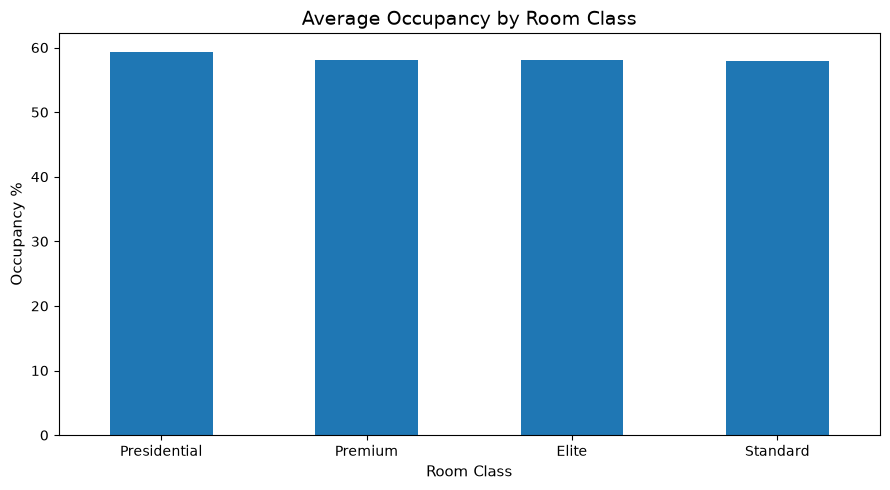

In [15]:
ax = room_occupancy.plot(
    x="room_class",
    y="avg_occupancy_pct",
    kind="bar",
    legend=False,
    figsize=(9, 5)
)
ax.set_title("Average Occupancy by Room Class")
ax.set_xlabel("Room Class")
ax.set_ylabel("Occupancy %")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [16]:
# Occupancy by city
city_occupancy = (
    occupancy.groupby("city", as_index=False)
    .agg(avg_occupancy_pct=("occ_pct", "mean"))
    .sort_values("avg_occupancy_pct", ascending=False)
)

city_occupancy


,city,avg_occupancy_pct
1,Delhi,61.51
2,Hyderabad,58.12
3,Mumbai,57.91
0,Bangalore,56.33


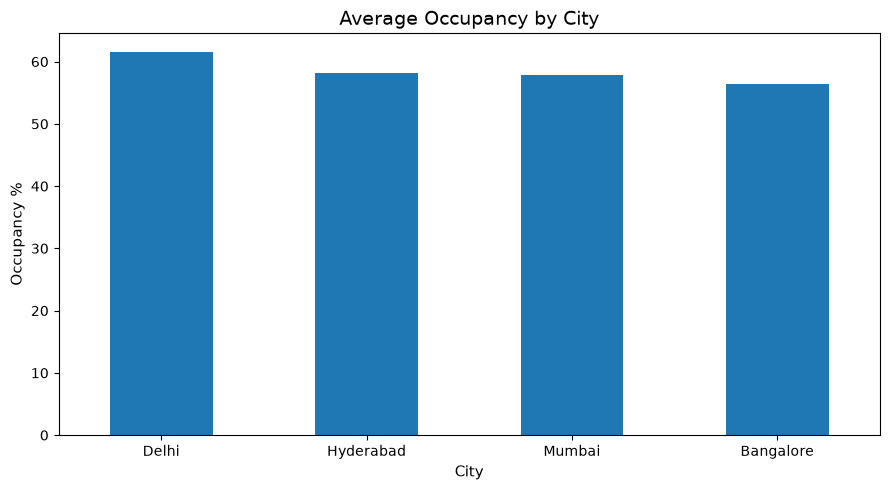

In [17]:
ax = city_occupancy.plot(
    x="city",
    y="avg_occupancy_pct",
    kind="bar",
    legend=False,
    figsize=(9, 5)
)
ax.set_title("Average Occupancy by City")
ax.set_xlabel("City")
ax.set_ylabel("Occupancy %")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


,day_type,avg_occupancy_pct
1,weekend,73.96
0,weekeday,51.81


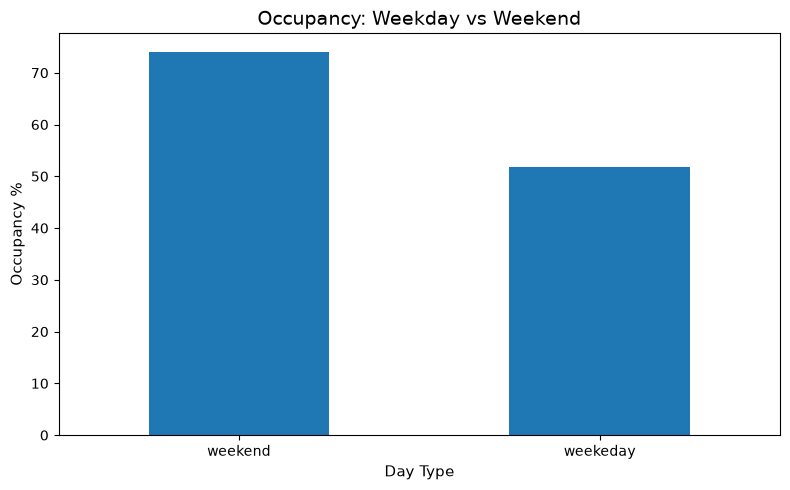

In [18]:
# Weekday vs weekend
if "day_type" in occupancy.columns:
    day_type_occupancy = (
        occupancy.groupby("day_type", as_index=False)
        .agg(avg_occupancy_pct=("occ_pct", "mean"))
        .sort_values("avg_occupancy_pct", ascending=False)
    )

    display(day_type_occupancy)

    ax = day_type_occupancy.plot(
        x="day_type",
        y="avg_occupancy_pct",
        kind="bar",
        legend=False,
        figsize=(8, 5)
    )
    ax.set_title("Occupancy: Weekday vs Weekend")
    ax.set_xlabel("Day Type")
    ax.set_ylabel("Occupancy %")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("day_type field not available in the date dimension.")


,mmm yy,avg_occupancy_pct
0,Jul 22,57.94
1,Jun 22,58.03
2,May 22,58.93


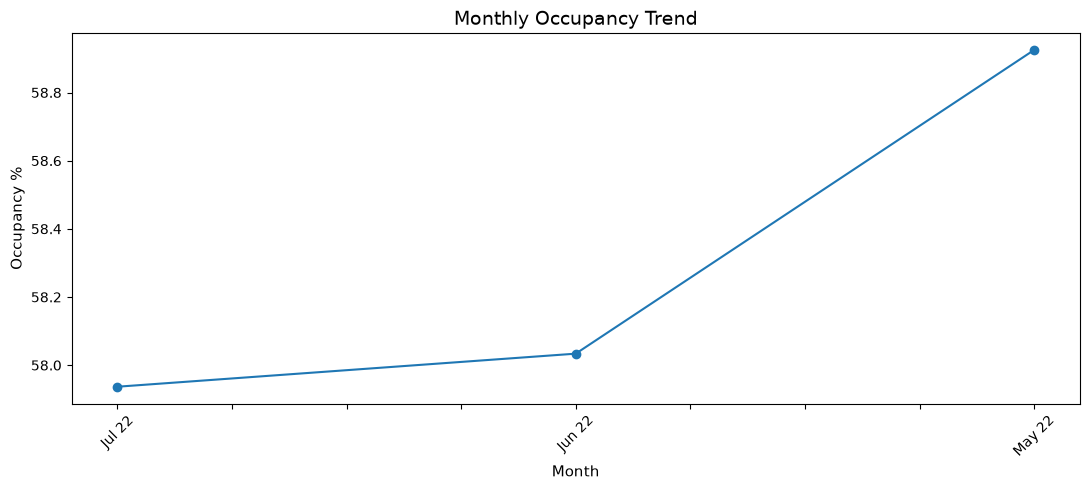

In [19]:
# Monthly occupancy
monthly_occupancy = (
    occupancy.groupby("mmm yy", as_index=False)
    .agg(avg_occupancy_pct=("occ_pct", "mean"))
)

display(monthly_occupancy)

ax = monthly_occupancy.plot(
    x="mmm yy",
    y="avg_occupancy_pct",
    kind="line",
    marker="o",
    legend=False,
    figsize=(11, 5)
)
ax.set_title("Monthly Occupancy Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Occupancy %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [20]:
# Property occupancy
property_occupancy = (
    occupancy.groupby(
        ["property_id", "property_name", "city"],
        as_index=False
    )
    .agg(avg_occupancy_pct=("occ_pct", "mean"))
    .sort_values("avg_occupancy_pct", ascending=False)
)

property_occupancy.head(15)


,property_id,property_name,city,avg_occupancy_pct
9,17561,Atliq Blu,Mumbai,68.28
0,16558,Atliq Grands,Delhi,67.70
15,18560,Atliq City,Hyderabad,66.38
5,16563,Atliq Palace,Delhi,66.29
7,17559,Atliq Exotica,Mumbai,66.20
11,17563,Atliq Palace,Mumbai,66.01
1,16559,Atliq Exotica,Mumbai,65.98
23,19562,Atliq Bay,Bangalore,65.95
17,18562,Atliq Bay,Hyderabad,65.88
3,16561,Atliq Blu,Delhi,65.79


# 11. Revenue Analysis

Revenue analysis focuses on:
- city contribution
- property contribution
- monthly trend
- revenue generated vs realized
- revenue leakage


In [21]:
# Revenue by city
revenue_city = (
    booking_analysis.groupby("city", as_index=False)
    .agg(
        revenue_generated=("revenue_generated", "sum"),
        revenue_realized=("revenue_realized", "sum"),
        revenue_loss=("revenue_loss", "sum"),
    )
    .sort_values("revenue_realized", ascending=False)
)

revenue_city


,city,revenue_generated,revenue_realized,revenue_loss
3,Mumbai,784786980,668569251,116217729
0,Bangalore,494814675,420383550,74431125
2,Hyderabad,381333250,325179310,56153940
1,Delhi,346350550,294404488,51946062


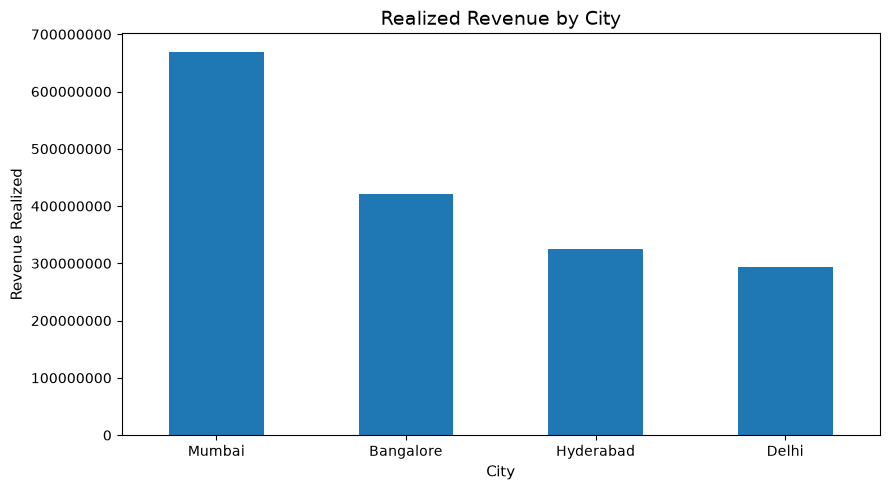

In [22]:
ax = revenue_city.plot(
    x="city",
    y="revenue_realized",
    kind="bar",
    legend=False,
    figsize=(9, 5)
)
ax.set_title("Realized Revenue by City")
ax.set_xlabel("City")
ax.set_ylabel("Revenue Realized")
plt.xticks(rotation=0)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


In [23]:
# Revenue by property
revenue_property = (
    booking_analysis.groupby(
        ["property_id", "property_name", "city"],
        as_index=False
    )
    .agg(
        revenue_generated=("revenue_generated", "sum"),
        revenue_realized=("revenue_realized", "sum"),
        revenue_loss=("revenue_loss", "sum"),
    )
    .sort_values("revenue_realized", ascending=False)
)

revenue_property.head(15)


,property_id,property_name,city,revenue_generated,revenue_realized,revenue_loss
1,16559,Atliq Exotica,Mumbai,138670020,118419858,20250162
11,17563,Atliq Palace,Mumbai,118616735,101511080,17105655
7,17559,Atliq Exotica,Mumbai,109685870,93992150,15693720
5,16563,Atliq Palace,Delhi,105200620,89135998,16064622
8,17560,Atliq City,Mumbai,103776330,87996216,15780114
23,19562,Atliq Bay,Bangalore,96540375,82443540,14096835
21,19560,Atliq City,Bangalore,97472625,81862845,15609780
6,17558,Atliq Grands,Mumbai,88430770,74730742,13700028
9,17561,Atliq Blu,Mumbai,86646790,73918312,12728478
22,19561,Atliq Blu,Bangalore,85807575,72963360,12844215


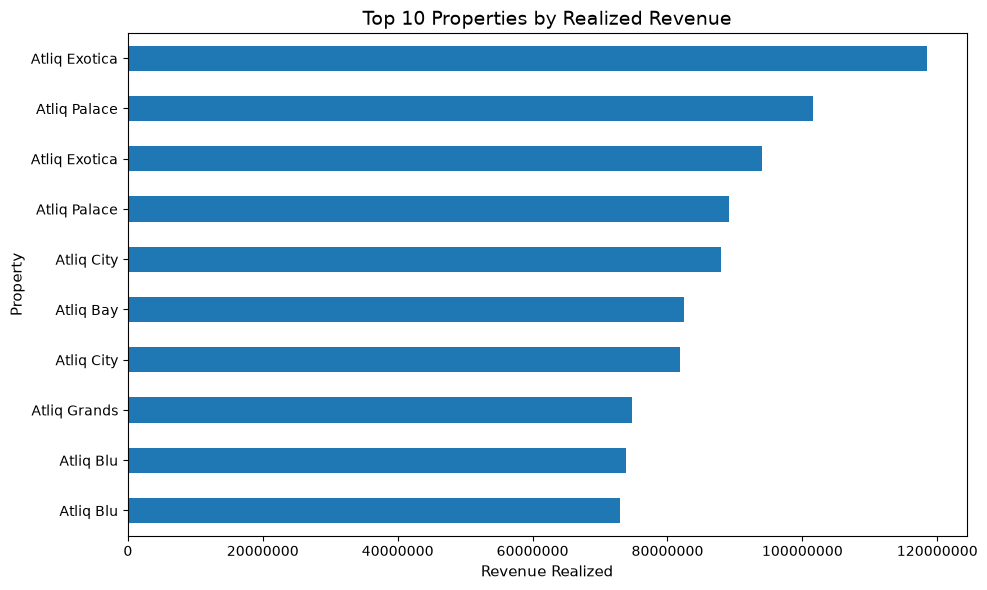

In [24]:
# Top 10 properties
top10_properties = (
    revenue_property
    .head(10)
    .sort_values("revenue_realized")
)

ax = top10_properties.plot(
    x="property_name",
    y="revenue_realized",
    kind="barh",
    legend=False,
    figsize=(10, 6)
)
ax.set_title("Top 10 Properties by Realized Revenue")
ax.set_xlabel("Revenue Realized")
ax.set_ylabel("Property")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()


,mmm yy,revenue_generated,revenue_realized,revenue_loss
0,Jul 22,285355820,243180932,42174888
1,Jun 22,270337980,229637640,40700340
2,May 22,276065375,234353183,41712192


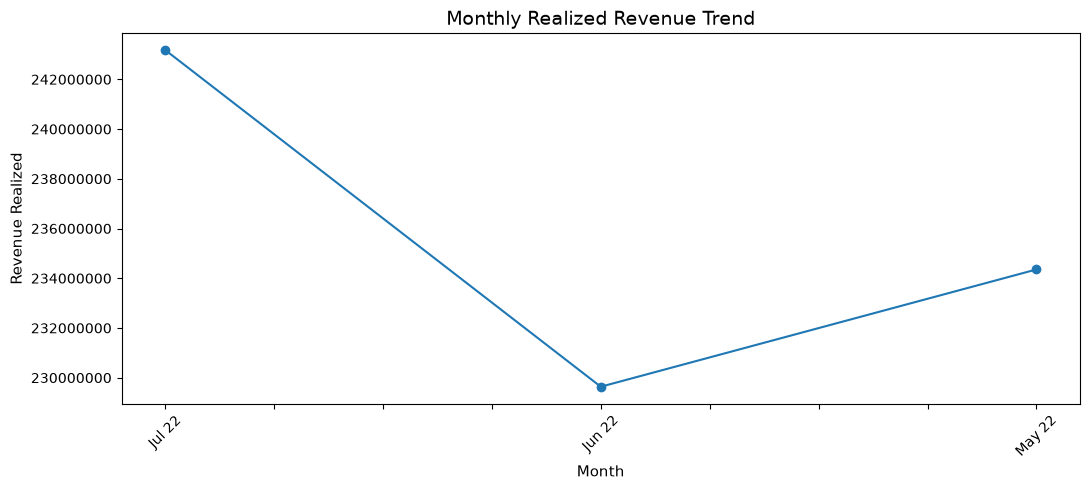

In [25]:
# Monthly revenue
monthly_revenue = (
    booking_analysis.groupby("mmm yy", as_index=False)
    .agg(
        revenue_generated=("revenue_generated", "sum"),
        revenue_realized=("revenue_realized", "sum"),
        revenue_loss=("revenue_loss", "sum"),
    )
)

display(monthly_revenue)

ax = monthly_revenue.plot(
    x="mmm yy",
    y="revenue_realized",
    kind="line",
    marker="o",
    legend=False,
    figsize=(11, 5)
)
ax.set_title("Monthly Realized Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue Realized")
plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


# 12. Booking Platform Analysis

A channel should not be evaluated only by booking volume.

We compare:
- booking count
- realized revenue
- average realized revenue per booking
- cancellation rate
- average rating


In [26]:
# Platform performance
platform_base = booking_analysis.assign(
    is_cancelled=(
        booking_analysis["booking_status"]
        .astype(str)
        .str.lower()
        .eq("cancelled")
    )
)

platform_summary = (
    platform_base.groupby("booking_platform")
    .agg(
        bookings=("booking_id", "count"),
        realized_revenue=("revenue_realized", "sum"),
        avg_revenue_per_booking=("revenue_realized", "mean"),
        cancellation_rate_pct=("is_cancelled", "mean"),
        avg_rating=("ratings_given", "mean"),
    )
    .reset_index()
)

platform_summary["cancellation_rate_pct"] *= 100

platform_summary = platform_summary.sort_values(
    "realized_revenue",
    ascending=False
)

platform_summary


,booking_platform,bookings,realized_revenue,avg_revenue_per_booking,cancellation_rate_pct,avg_rating
5,others,55061,699306762,"12,700.58",24.87,3.62
4,makeyourtrip,26896,340814104,"12,671.55",24.99,3.62
3,logtrip,14753,187494028,"12,708.87",24.31,3.62
1,direct online,13374,168948637,"12,632.62",25.00,3.61
6,tripster,9630,123066801,"12,779.52",24.99,3.62
2,journey,8106,102531334,"12,648.82",24.78,3.63
0,direct offline,6753,86374933,"12,790.60",24.49,3.62


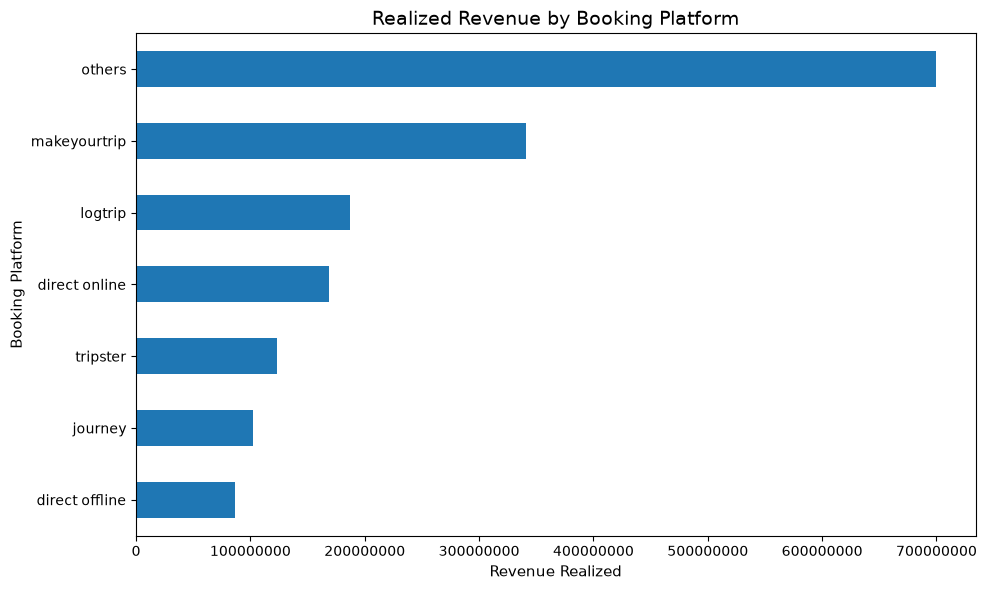

In [27]:
ax = platform_summary.sort_values("realized_revenue").plot(
    x="booking_platform",
    y="realized_revenue",
    kind="barh",
    legend=False,
    figsize=(10, 6)
)
ax.set_title("Realized Revenue by Booking Platform")
ax.set_xlabel("Revenue Realized")
ax.set_ylabel("Booking Platform")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()


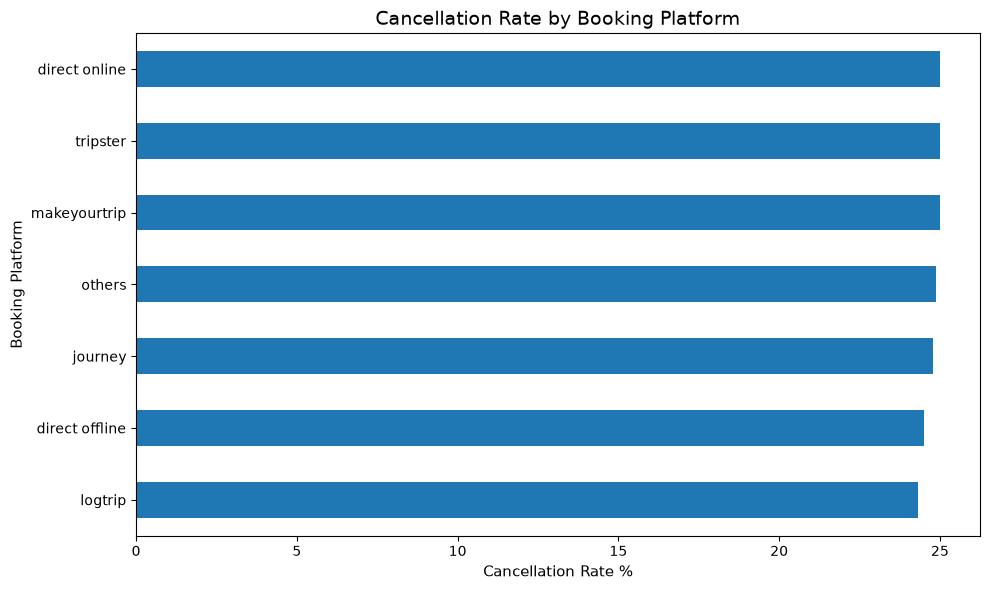

In [28]:
ax = platform_summary.sort_values("cancellation_rate_pct").plot(
    x="booking_platform",
    y="cancellation_rate_pct",
    kind="barh",
    legend=False,
    figsize=(10, 6)
)
ax.set_title("Cancellation Rate by Booking Platform")
ax.set_xlabel("Cancellation Rate %")
ax.set_ylabel("Booking Platform")
plt.tight_layout()
plt.show()


# 13. Cancellation & Revenue Leakage

Cancellation and no-show behavior can create a gap between revenue that was generated at booking and revenue ultimately realized.

We calculate the gap directly from:

```text
Revenue Loss = Revenue Generated − Revenue Realized
```

This is a **dataset-specific revenue leakage measure**, not a claim that all of the difference represents cancellation loss.


In [29]:
# Booking status summary
status_summary = (
    booking_analysis.groupby("booking_status")
    .agg(
        bookings=("booking_id", "count"),
        revenue_generated=("revenue_generated", "sum"),
        revenue_realized=("revenue_realized", "sum"),
        revenue_loss=("revenue_loss", "sum"),
    )
    .reset_index()
)

status_summary["realization_rate_pct"] = np.where(
    status_summary["revenue_generated"] != 0,
    status_summary["revenue_realized"] /
    status_summary["revenue_generated"] * 100,
    np.nan
)

status_summary


,booking_status,bookings,revenue_generated,revenue_realized,revenue_loss,realization_rate_pct
0,Cancelled,33416,497914760,199165904,298748856,40.00
1,Checked Out,94399,1408917655,1408917655,0,100.00
2,No Show,6758,100453040,100453040,0,100.00


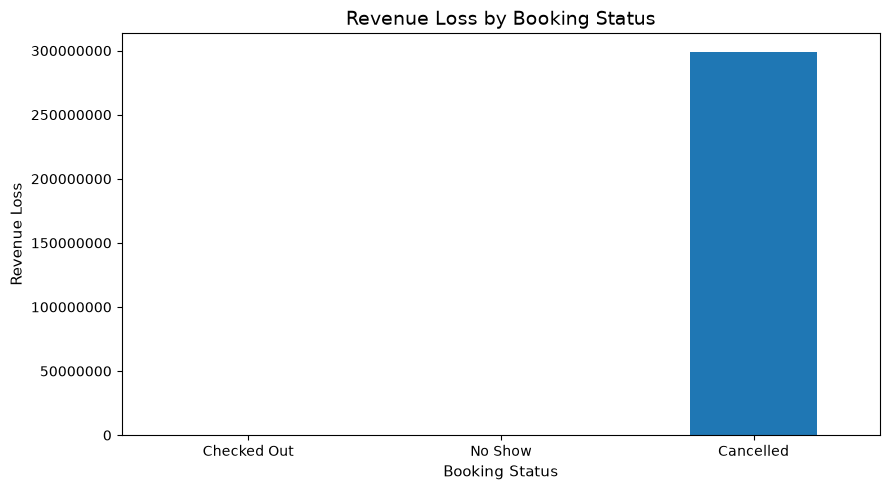

In [30]:
ax = status_summary.sort_values("revenue_loss").plot(
    x="booking_status",
    y="revenue_loss",
    kind="bar",
    legend=False,
    figsize=(9, 5)
)
ax.set_title("Revenue Loss by Booking Status")
ax.set_xlabel("Booking Status")
ax.set_ylabel("Revenue Loss")
plt.xticks(rotation=0)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


In [31]:
# Cancellation rate by city
cancellation_city = (
    platform_base.groupby("city")["is_cancelled"]
    .mean()
    .mul(100)
    .reset_index(name="cancellation_rate_pct")
    .sort_values("cancellation_rate_pct", ascending=False)
)

cancellation_city


,city,cancellation_rate_pct
1,Delhi,25.06
0,Bangalore,24.99
3,Mumbai,24.75
2,Hyderabad,24.63


# 14. Customer Experience Analysis

Ratings are analyzed without imputing missing values.

This allows management to compare customer experience across:
- cities
- properties
- booking platforms


In [32]:
# Average rating by city
rating_city = (
    booking_analysis.groupby("city", as_index=False)
    .agg(avg_rating=("ratings_given", "mean"))
    .sort_values("avg_rating", ascending=False)
)

rating_city


,city,avg_rating
1,Delhi,3.78
2,Hyderabad,3.66
3,Mumbai,3.65
0,Bangalore,3.41


In [33]:
# Average rating by property
rating_property = (
    booking_analysis.groupby(
        ["property_id", "property_name", "city"],
        as_index=False
    )
    .agg(avg_rating=("ratings_given", "mean"))
    .sort_values("avg_rating", ascending=False)
)

rating_property.head(15)


,property_id,property_name,city,avg_rating
1,16559,Atliq Exotica,Mumbai,4.32
7,17559,Atliq Exotica,Mumbai,4.32
17,18562,Atliq Bay,Hyderabad,4.30
9,17561,Atliq Blu,Mumbai,4.30
11,17563,Atliq Palace,Mumbai,4.29
21,19560,Atliq City,Bangalore,4.28
23,19562,Atliq Bay,Bangalore,4.28
3,16561,Atliq Blu,Delhi,4.28
5,16563,Atliq Palace,Delhi,4.27
15,18560,Atliq City,Hyderabad,4.26


In [34]:
# Average rating by platform
rating_platform = (
    booking_analysis.groupby("booking_platform", as_index=False)
    .agg(avg_rating=("ratings_given", "mean"))
    .sort_values("avg_rating", ascending=False)
)

rating_platform


,booking_platform,avg_rating
2,journey,3.63
3,logtrip,3.62
0,direct offline,3.62
6,tripster,3.62
5,others,3.62
4,makeyourtrip,3.62
1,direct online,3.61


# 15. Property Performance Scorecard

A management scorecard combines:

- realized revenue
- average occupancy
- booking volume
- cancellation rate
- customer rating

The scorecard is **descriptive**. No arbitrary weighted score is imposed because the dataset does not tell us management's priorities.


In [35]:
property_booking_metrics = (
    platform_base.groupby("property_id")
    .agg(
        bookings=("booking_id", "count"),
        realized_revenue=("revenue_realized", "sum"),
        cancellation_rate_pct=("is_cancelled", "mean"),
    )
    .reset_index()
)

property_booking_metrics["cancellation_rate_pct"] *= 100

property_scorecard = (
    property_occupancy
    .merge(
        property_booking_metrics,
        on="property_id",
        how="left"
    )
    .merge(
        rating_property[
            ["property_id", "avg_rating"]
        ],
        on="property_id",
        how="left"
    )
    .sort_values("realized_revenue", ascending=False)
)

property_scorecard[
    [
        "property_id",
        "property_name",
        "city",
        "realized_revenue",
        "avg_occupancy_pct",
        "bookings",
        "cancellation_rate_pct",
        "avg_rating",
    ]
].head(20)


,property_id,property_name,city,realized_revenue,avg_occupancy_pct,bookings,cancellation_rate_pct,avg_rating
6,16559,Atliq Exotica,Mumbai,118419858,65.98,7337,24.61,4.32
5,17563,Atliq Palace,Mumbai,101511080,66.01,6337,24.38,4.29
4,17559,Atliq Exotica,Mumbai,93992150,66.20,6141,24.00,4.32
3,16563,Atliq Palace,Delhi,89135998,66.29,7147,25.26,4.27
20,17560,Atliq City,Mumbai,87996216,52.94,6013,25.06,3.04
7,19562,Atliq Bay,Bangalore,82443540,65.95,5812,24.33,4.28
10,19560,Atliq City,Bangalore,81862845,65.63,5978,26.38,4.28
14,17558,Atliq Grands,Mumbai,74730742,53.91,5036,25.66,3.05
0,17561,Atliq Blu,Mumbai,73918312,68.28,5183,24.52,4.30
18,19561,Atliq Blu,Bangalore,72963360,53.20,5736,24.65,3.08


# 16. Property Opportunity Segmentation

To support management prioritization, properties are classified using median thresholds:

- **Protect & Scale** — above-median revenue and occupancy
- **Pricing / Revenue Opportunity** — above-median occupancy but below-median revenue
- **Demand / Conversion Opportunity** — above-median revenue but below-median occupancy
- **Turnaround Candidate** — below-median revenue and occupancy

These are **screening categories**, not predictive models.


In [36]:
revenue_median = property_scorecard["realized_revenue"].median()
occupancy_median = property_scorecard["avg_occupancy_pct"].median()

def classify_property(row):
    high_revenue = row["realized_revenue"] >= revenue_median
    high_occupancy = row["avg_occupancy_pct"] >= occupancy_median

    if high_revenue and high_occupancy:
        return "Protect & Scale"
    elif high_occupancy and not high_revenue:
        return "Pricing / Revenue Opportunity"
    elif high_revenue and not high_occupancy:
        return "Demand / Conversion Opportunity"
    return "Turnaround Candidate"

property_scorecard["performance_segment"] = (
    property_scorecard.apply(classify_property, axis=1)
)

property_scorecard[
    [
        "property_name",
        "city",
        "realized_revenue",
        "avg_occupancy_pct",
        "avg_rating",
        "cancellation_rate_pct",
        "performance_segment",
    ]
]


,property_name,city,realized_revenue,avg_occupancy_pct,avg_rating,cancellation_rate_pct,performance_segment
6,Atliq Exotica,Mumbai,118419858,65.98,4.32,24.61,Protect & Scale
5,Atliq Palace,Mumbai,101511080,66.01,4.29,24.38,Protect & Scale
4,Atliq Exotica,Mumbai,93992150,66.20,4.32,24.00,Protect & Scale
3,Atliq Palace,Delhi,89135998,66.29,4.27,25.26,Protect & Scale
20,Atliq City,Mumbai,87996216,52.94,3.04,25.06,Demand / Conversion Opportunity
7,Atliq Bay,Bangalore,82443540,65.95,4.28,24.33,Protect & Scale
10,Atliq City,Bangalore,81862845,65.63,4.28,26.38,Protect & Scale
14,Atliq Grands,Mumbai,74730742,53.91,3.05,25.66,Demand / Conversion Opportunity
0,Atliq Blu,Mumbai,73918312,68.28,4.30,24.52,Protect & Scale
18,Atliq Blu,Bangalore,72963360,53.20,3.08,24.65,Demand / Conversion Opportunity


In [37]:
# Segment distribution
segment_counts = (
    property_scorecard["performance_segment"]
    .value_counts()
    .rename_axis("performance_segment")
    .reset_index(name="properties")
)

segment_counts


,performance_segment,properties
0,Protect & Scale,8
1,Turnaround Candidate,7
2,Demand / Conversion Opportunity,5
3,Pricing / Revenue Opportunity,5


# 17. Revenue vs Occupancy Diagnostic

Revenue alone can hide demand problems.

A property with:
- high occupancy + low revenue may have a pricing/mix opportunity
- low occupancy + high revenue may have a demand/conversion opportunity
- high occupancy + high revenue may be a strong performer
- low occupancy + low revenue may need a turnaround plan

The scatter plot provides a portfolio-level diagnostic.


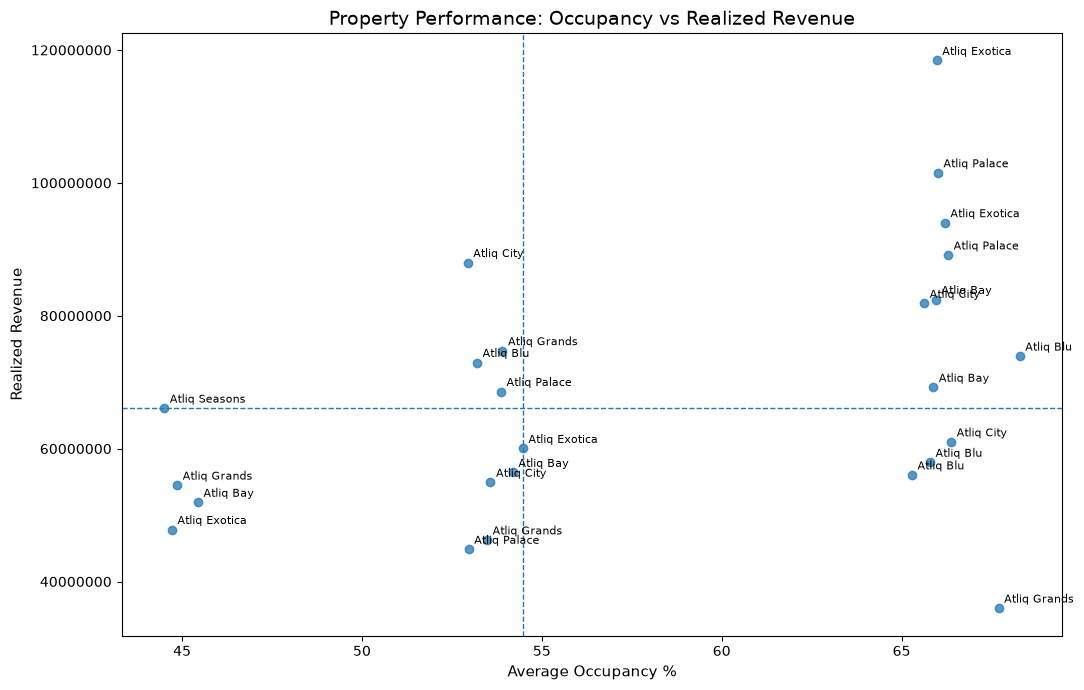

In [38]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    property_scorecard["avg_occupancy_pct"],
    property_scorecard["realized_revenue"],
    alpha=0.75
)

for _, row in property_scorecard.iterrows():
    ax.annotate(
        row["property_name"],
        (row["avg_occupancy_pct"], row["realized_revenue"]),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

ax.axvline(occupancy_median, linestyle="--", linewidth=1)
ax.axhline(revenue_median, linestyle="--", linewidth=1)

ax.set_title("Property Performance: Occupancy vs Realized Revenue")
ax.set_xlabel("Average Occupancy %")
ax.set_ylabel("Realized Revenue")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


# 18. June Analysis

The original project includes a focused June occupancy comparison.

We retain it as a business question:

> Which city had the strongest average occupancy during June?


,city,avg_occupancy_pct
1,Delhi,61.46
3,Mumbai,57.79
2,Hyderabad,57.69
0,Bangalore,55.85


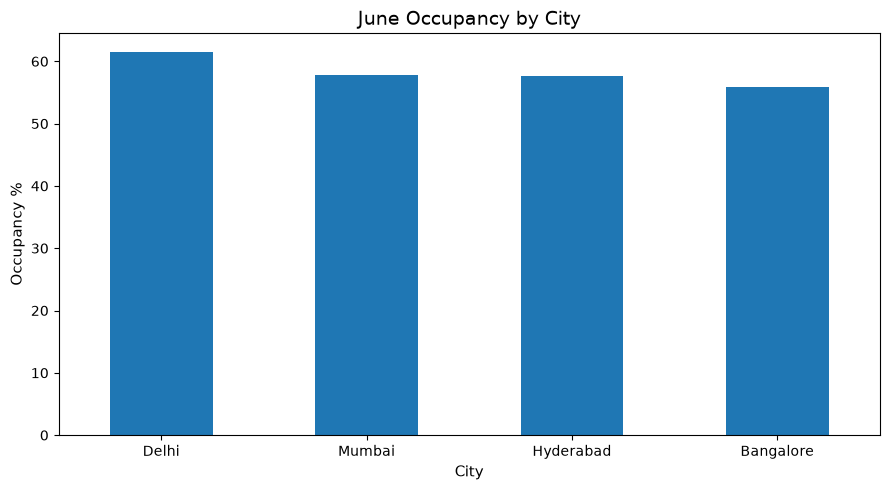

In [39]:
if "mmm yy" in occupancy.columns:
    june_rows = occupancy[
        occupancy["mmm yy"].astype(str).str.lower().eq("jun 22")
    ]

    if june_rows.empty:
        # More robust fallback for date-based June identification
        june_rows = occupancy[
            occupancy["check_in_date"].dt.month.eq(6)
        ]

    june_city_occupancy = (
        june_rows.groupby("city", as_index=False)
        .agg(avg_occupancy_pct=("occ_pct", "mean"))
        .sort_values("avg_occupancy_pct", ascending=False)
    )

    display(june_city_occupancy)

    if not june_city_occupancy.empty:
        ax = june_city_occupancy.plot(
            x="city",
            y="avg_occupancy_pct",
            kind="bar",
            legend=False,
            figsize=(9, 5)
        )
        ax.set_title("June Occupancy by City")
        ax.set_xlabel("City")
        ax.set_ylabel("Occupancy %")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()
else:
    print("Month field not available.")


# 19. Incremental August Data

The project includes `new_data_august.csv`.

Rather than blindly concatenating it, we inspect its schema first.

This demonstrates a practical analyst workflow for handling periodic incoming data.


In [40]:
if df_august is not None:
    print("August columns:")
    print(list(df_august.columns))
    print("\nAugust shape:", df_august.shape)
    display(df_august.head())

    expected_booking_columns = set(bookings.columns)
    august_columns = set(df_august.columns)

    missing_in_august = sorted(expected_booking_columns - august_columns)

    if missing_in_august:
        print("\nAugust file is not directly schema-compatible with the booking fact table.")
        print("Missing columns:", missing_in_august)
    else:
        bookings_with_august = pd.concat(
            [bookings, df_august[bookings.columns]],
            ignore_index=True
        )
        print("\nAugust data appended successfully.")
        print("Combined booking rows:", len(bookings_with_august))
else:
    print("Optional August file not available.")


August columns:
['property_id', 'property_name', 'category', 'city', 'room_category', 'room_class', 'check_in_date', 'mmm yy', 'week no', 'day_type', 'successful_bookings', 'capacity', 'occ%']

August shape: (7, 13)


,property_id,property_name,category,city,room_category,room_class,check_in_date,mmm yy,week no,day_type,successful_bookings,capacity,occ%
0,16559,Atliq Exotica,Luxury,Mumbai,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,30,30,100.00
1,19562,Atliq Bay,Luxury,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,21,30,70.00
2,19563,Atliq Palace,Business,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,23,30,76.67
3,19558,Atliq Grands,Luxury,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,30,40,75.00
4,19560,Atliq City,Business,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,20,26,76.92



August file is not directly schema-compatible with the booking fact table.
Missing columns: ['booking_date', 'booking_id', 'booking_platform', 'booking_status', 'checkout_date', 'no_guests', 'ratings_given', 'revenue_generated', 'revenue_realized']


# 20. Key Business Insights

The following values are generated directly from the analysis above.

The objective is to move from:

> **"What happened?"**

to:

> **"Why does it matter and what should management investigate?"**


In [41]:
# ============================================================
# 20. Generate data-driven insight statements
# ============================================================

top_revenue_city = revenue_city.iloc[0]
top_occupancy_city = city_occupancy.iloc[0]
lowest_occupancy_city = city_occupancy.iloc[-1]
top_room_class = room_occupancy.iloc[0]
top_property = revenue_property.iloc[0]
top_platform = platform_summary.iloc[0]

insight_statements = []

insight_statements.append(
    f"Revenue leadership: {top_revenue_city['city']} generated "
    f"{top_revenue_city['revenue_realized']:,.0f} in realized revenue."
)

insight_statements.append(
    f"Occupancy leadership: {top_occupancy_city['city']} recorded "
    f"{top_occupancy_city['avg_occupancy_pct']:.2f}% average occupancy, "
    f"while {lowest_occupancy_city['city']} recorded "
    f"{lowest_occupancy_city['avg_occupancy_pct']:.2f}%."
)

insight_statements.append(
    f"Room demand: {top_room_class['room_class']} had the highest "
    f"average occupancy at {top_room_class['avg_occupancy_pct']:.2f}%."
)

if "day_type" in occupancy.columns:
    best_day = day_type_occupancy.iloc[0]
    worst_day = day_type_occupancy.iloc[-1]

    insight_statements.append(
        f"Demand timing: {best_day['day_type']} occupancy averaged "
        f"{best_day['avg_occupancy_pct']:.2f}% versus "
        f"{worst_day['avg_occupancy_pct']:.2f}% for {worst_day['day_type']}."
    )

insight_statements.append(
    f"Property leadership: {top_property['property_name']} generated "
    f"{top_property['revenue_realized']:,.0f} in realized revenue."
)

insight_statements.append(
    f"Channel leadership: {top_platform['booking_platform']} generated "
    f"{top_platform['realized_revenue']:,.0f} in realized revenue."
)

for i, statement in enumerate(insight_statements, 1):
    print(f"{i}. {statement}")


1. Revenue leadership: Mumbai generated 668,569,251 in realized revenue.
2. Occupancy leadership: Delhi recorded 61.51% average occupancy, while Bangalore recorded 56.33%.
3. Room demand: Presidential had the highest average occupancy at 59.28%.
4. Demand timing: weekend occupancy averaged 73.96% versus 51.81% for weekeday.
5. Property leadership: Atliq Exotica generated 118,419,858 in realized revenue.
6. Channel leadership: others generated 699,306,762 in realized revenue.


# 21. Business Recommendations

## Recommendation 1 — Strengthen weekday demand

If weekend occupancy materially exceeds weekday occupancy, investigate:
- corporate/business-traveller packages
- weekday promotions
- differentiated pricing
- local corporate partnerships

## Recommendation 2 — Protect high-performing properties

High-revenue/high-occupancy properties should be monitored for:
- capacity constraints
- lost demand
- pricing opportunities
- service-quality consistency

## Recommendation 3 — Review high-cancellation channels

For channels with elevated cancellation rates, investigate:
- cancellation policies
- booking lead time
- discounting
- customer mix
- channel economics

## Recommendation 4 — Prioritize underperforming properties

Properties with low occupancy and low revenue should be investigated by:
- city
- room class
- booking platform
- customer rating
- booking status

## Recommendation 5 — Connect customer experience to commercial performance

Properties with high revenue but relatively weak ratings should be reviewed for service-quality risks that could affect future demand.

> These recommendations are analytical hypotheses. Pricing, marketing spend, inventory and customer-segment data would be needed to validate the underlying causes.


# 22. Portfolio-Ready Conclusion

### What this project demonstrates

**Technical**
- Python
- Pandas
- NumPy
- data profiling
- data cleaning
- missing-value handling
- outlier detection
- relational joins
- aggregation
- KPI development
- visualization
- incremental data validation

**Business**
- hotel revenue analysis
- occupancy analysis
- property benchmarking
- booking-channel analysis
- cancellation analysis
- customer experience analysis
- performance segmentation
- business recommendations

### Recommended project title

**AtliQ Hotels Revenue & Occupancy Analytics**

### Recommended portfolio description

> Built an end-to-end hotel analytics solution using Python and Pandas to clean and validate booking data, integrate fact and dimension tables, develop revenue and occupancy KPIs, benchmark properties and booking channels, identify performance gaps, and translate analytical findings into actionable business recommendations.


# 23. Reproducibility Checklist

Before publishing to GitHub:

- [ ] Place all source CSVs under `data/raw/`
- [ ] Keep this notebook under `notebooks/`
- [ ] Run **Kernel → Restart & Run All**
- [ ] Confirm the data path resolves correctly
- [ ] Verify the date parsing
- [ ] Verify no invalid occupancy records remain
- [ ] Review all generated insights
- [ ] Save selected charts into `outputs/figures/` if required
- [ ] Add `requirements.txt`
- [ ] Add `.gitignore`
- [ ] Add a professional `README.md`
- [ ] Add project screenshots
- [ ] Commit the project to Git
- [ ] Push to GitHub


# Appendix — Analyst Notes

### Why ADR / RevPAR are not forced into this notebook

The supplied dataset supports strong occupancy and revenue analysis, but portfolio work should not manufacture industry KPIs without clearly defined denominators.

If future data provides reliable:
- available room inventory
- room-night inventory
- room rate / daily selling price

then ADR and RevPAR can be added with explicit definitions.

### Data interpretation principle

Every business conclusion in this notebook should be traceable to:
1. a source field,
2. a documented transformation,
3. a reproducible calculation,
4. a visual or table,
5. and a clearly stated interpretation.

That is the standard this project is designed to demonstrate.
